# 6. Interpolación

## Librerias

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Imagen de referencia

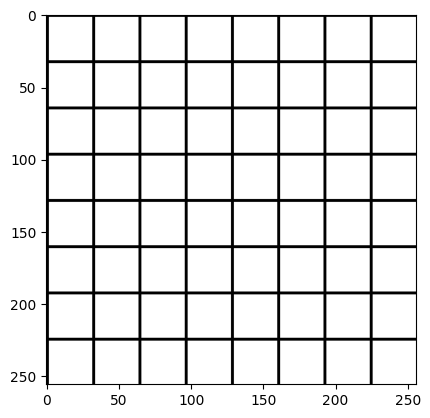

In [2]:
img = np.full((256,256,3),255,dtype=np.uint8)

for i in range(0,256,int(256/8)):
  img[i:i+2,:] = 0
  img[:,i:i+2] = 0


plt.imshow(img)
plt.show()

## Submuestreo (128x128)

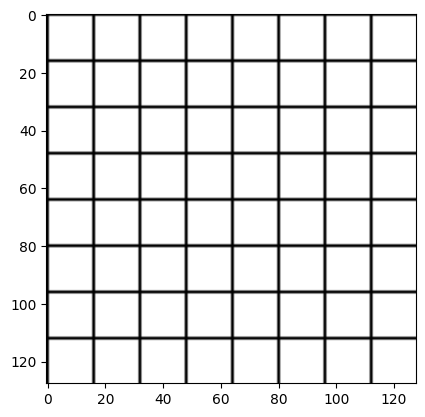

In [3]:
img_r = cv2.resize(img, dsize=(128,128) ,interpolation=cv2.INTER_NEAREST)

plt.imshow(img_r)
plt.show()

Lo que sucede al realizar muestreo sobre la imagen a la mitad de su tamaño original es que, al tener menos valores de píxel pero igual area de imagen, cada pixel debe graficarse en un area cuatro veces mayor para poder cubrir la misma area que la imagen original. Por lo tanto la resolución de la imagen o tamaño de píxel en la imagen 128x128 es cuatro veces la de la imagen original de 256x256

## Tecnicas de submuestreo (128x128)

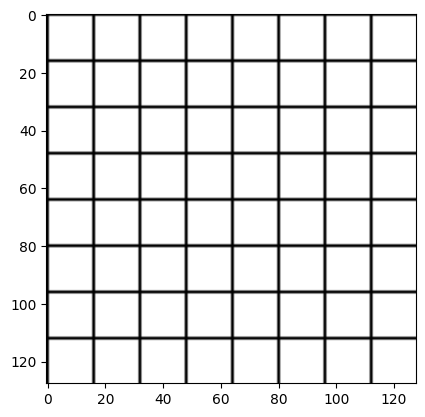

Los valores unicos de esta imagen son: [  0 255]


In [4]:
# Nearest Neighbor
img_r = cv2.resize(img, (128,128),interpolation=cv2.INTER_NEAREST)

plt.imshow(img_r)
plt.show()

print(f'Los valores unicos de esta imagen son: {np.unique(img_r)}')

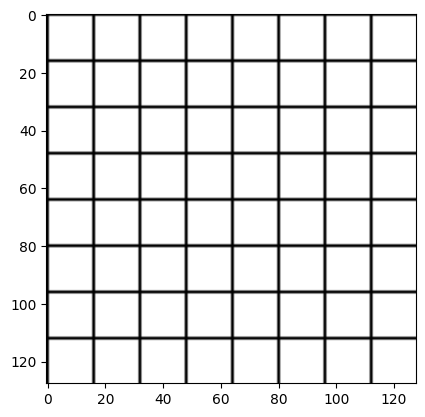

Los valores unicos de esta imagen son: [  0 255]


In [5]:
# Interpolacion lineal
img_r = cv2.resize(img, (128,128),interpolation=cv2.INTER_LINEAR)

plt.imshow(img_r)
plt.show()

print(f'Los valores unicos de esta imagen son: {np.unique(img_r)}')

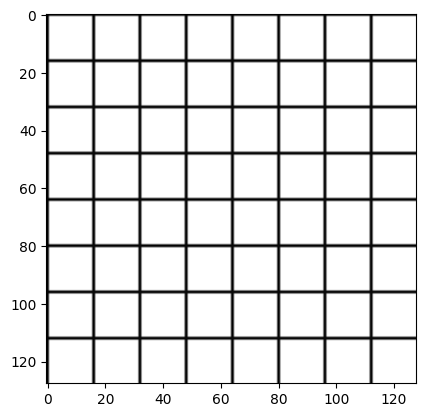

Los valores unicos de esta imagen son: [  0   2   4   9 255]


In [6]:
# Interpolación cúbica
img_r = cv2.resize(img, (128,128),interpolation=cv2.INTER_CUBIC)

plt.imshow(img_r)
plt.show()

print(f'Los valores unicos de esta imagen son: {np.unique(img_r)}')

Basandonos en la apariencia de las imagenes anteriores donde se aplicó tres tecnicas de submuestreo a la imagen original, se observa que las tres imagenes tienen una apariencia igual entre ellas. Sin embargo, cuando observamos los niveles de grises presentes en estas vemos una diferencia y esto se debe a cómo funciona la tecnica seleccionada. 

La primera imagen se aplica Nearest Neighbor la cual toma el valor de pixel mas cercano a las nuevas coordenadas, esto quiere decir que, se toma valores de la imagen y no se crean nuevos, por lo tanto los niveles de gris en la primera tecnica son los mismos que la original.

En la segunda imagen se aplicó una interpolación lineal. Esta tecnica usa los valores de cuatro vecinos mas cercanos a la nueva coordenada y calcula el valor aplicando una suma ponderada de estos. En este caso, no se agregaron escalas de grises, esto puede deberse a las pocas escalas de grises presentes en la imagen y la relacion de 0.5 en el cambio de dimensiones. Esto generó que al calcular los valores de nuevas coordenadas sean iguales a algun vecino es decir blanco o negro.

Por ultimo, se aplicó la tecnica de interpolación cubica, la cual si generó escalas de grises nuevas, tres escalas nuevas de 2, 4 y 9. Esto es producto de la aplicación de un polinomio cúbico entre 16 vecinos a la nueva coordenada.

## Tecnicas de submuestreo (100x100)

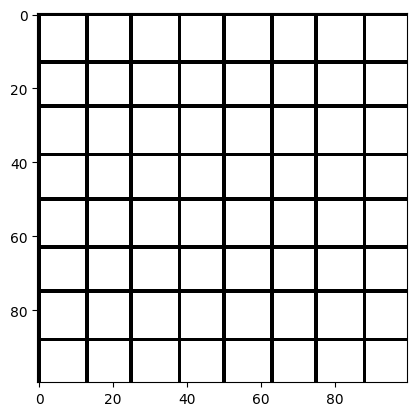

Los valores unicos de esta imagen son: [  0 255]


In [7]:
# Nearest Neighbor
img_r = cv2.resize(img, (100,100),interpolation=cv2.INTER_NEAREST)

plt.imshow(img_r)
plt.show()

print(f'Los valores unicos de esta imagen son: {np.unique(img_r)}')

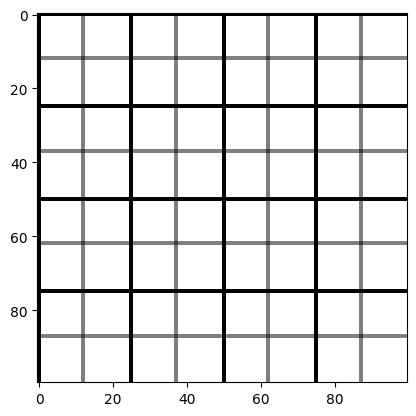

Los valores unicos de esta imagen son: [  0  64 127 128 255]


In [8]:
# Interpolacion lineal
img_r = cv2.resize(img, (100,100),interpolation=cv2.INTER_LINEAR)

plt.imshow(img_r)
plt.show()

print(f'Los valores unicos de esta imagen son: {np.unique(img_r)}')


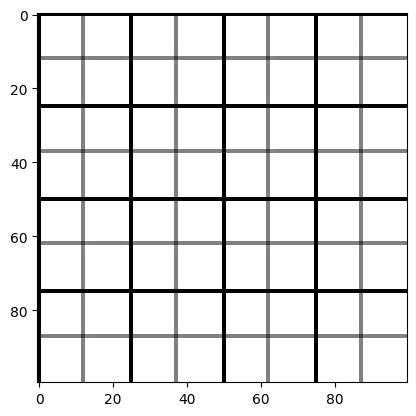

Los valores unicos de esta imagen son: [  0   3   4  64 127 128 131 133 255]


In [9]:
# Interpolacion cubica
img_r = cv2.resize(img, (100,100),interpolation=cv2.INTER_CUBIC)

plt.imshow(img_r)
plt.show()

print(f'Los valores unicos de esta imagen son: {np.unique(img_r)}')

Esta vez, como las dimensiones son menores y desproporcionales a las originales, se observa diferencia frenta a las imagenes anteriores. Esta vez, se crearon escalas de gris al usar la tecnica lineal y aun mas en el caso cúbico. Además, las imagenes presentan diferencias en su aspecto en especial las imagenes generadas por interpolación lineal y cúbica. Estas imagenes se distorcionaron y algunas de las barras negras ahora se ven de color gris.

## Submuestreo (Torax.png)

In [10]:
def plot_imgs_side_by_side(img1, img2, title1='muscle, spot', title2='spot, muscle'):
  """ funcion para mostrar dos imagenes en la misma figura """
  fig, axes = plt.subplots(1, 2, figsize=(8, 4))

  axes[0].imshow(img1)
  axes[0].set_title(title1)
  axes[0].axis("off")

  axes[1].imshow(img2)
  axes[1].set_title(title2)
  axes[1].axis("off")

  plt.tight_layout()
  plt.show()

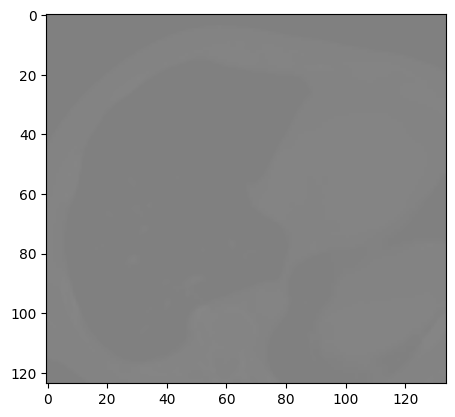

In [12]:
img = cv2.imread('../img/Torax.png')

plt.imshow(img)
plt.show()

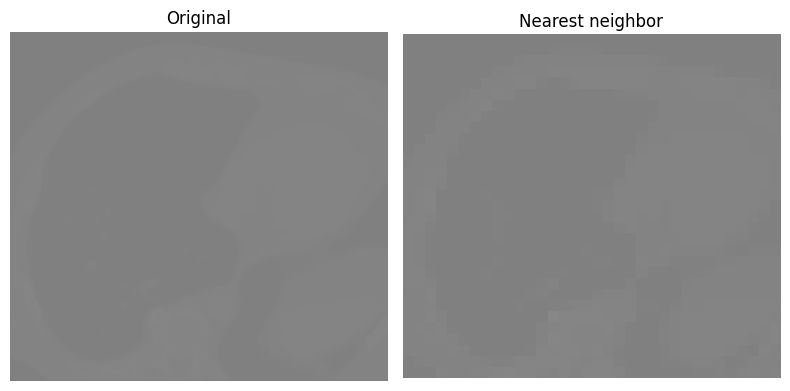

In [13]:
# Nearest Neighbor
img_r = cv2.resize(img, (34,31),interpolation=cv2.INTER_NEAREST)

plot_imgs_side_by_side(img, img_r, title1='Original', title2='Nearest neighbor')

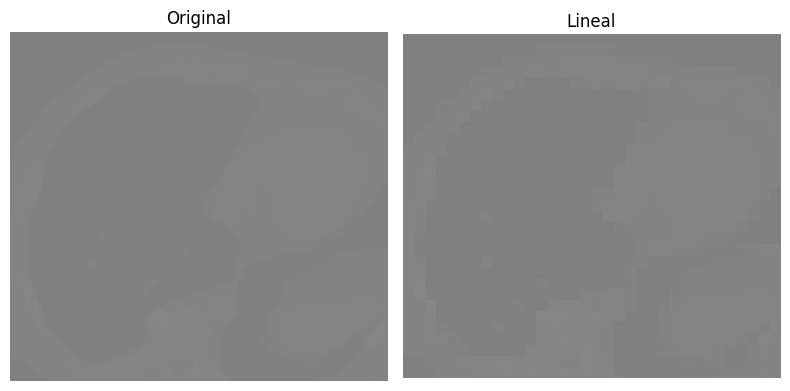

In [14]:
# Interpolacion lineal
img_r_lineal = cv2.resize(img, (34,31),interpolation=cv2.INTER_LINEAR)

plot_imgs_side_by_side(img, img_r_lineal, title1='Original', title2='Lineal')


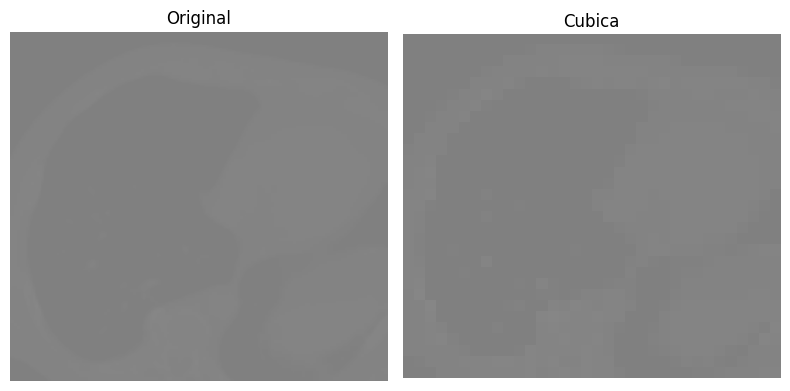

In [15]:
# Interpolacion cubica
img_r_cublic = cv2.resize(img, (34,31),interpolation=cv2.INTER_CUBIC)

plot_imgs_side_by_side(img, img_r_cublic, title1='Original', title2='Cubica')

Partiendo de la comparativa anterior donde se presenta tres tecnicas de interpolado aplicadas a la image de torax, se observa que en todos los casos la apariencia cambia, las curvas de la imagen desaparecen y en su lugar se presentan picos rectangulares. En la tecnica de nearest neighbor, la imagen se presenta de una forma más fidedigna si se observa que en ambas imagenes se puede obervar una zona clara dentro de una zona oscura mas grande. Por el contrario, en el interpolado lineal y cubico estas zonas internas se agrandan e incluso aparecen zonas que no eran visibles en la imagen original.

## Remuestreo

In [16]:
# lineal
img_lineal = cv2.resize(img_r_lineal, (134,124),interpolation=cv2.INTER_LINEAR)
img_lineal_2x = cv2.resize(img_lineal, None, fx=2, fy=2 ,interpolation=cv2.INTER_LINEAR)

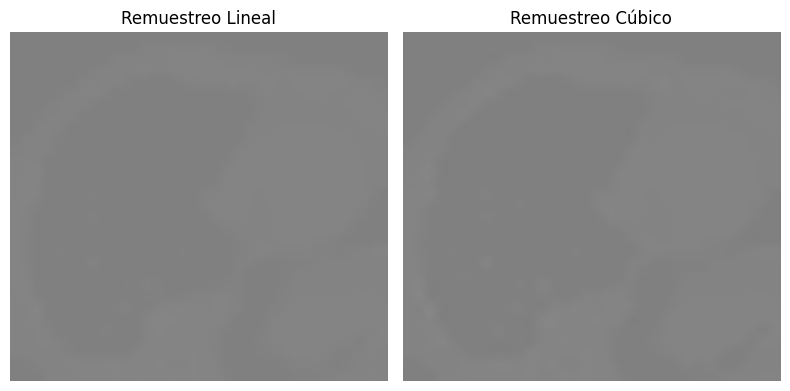

In [17]:
# cubico
img_cubic = cv2.resize(img_r_cublic, (134,124),interpolation=cv2.INTER_CUBIC)
img_cubic_2x = cv2.resize(img_cubic, None, fx=2, fy=2 ,interpolation=cv2.INTER_CUBIC)


plot_imgs_side_by_side(img_lineal_2x, img_cubic_2x, title1='Remuestreo Lineal', title2='Remuestreo Cúbico')

Al duplicar el numero de filas y columnas de la imagen manteniendo el area igual, el tamaño del pixel ahora es mas pequeño. Al momento de graficarla en pantalla ahora deben caber mas pixeles en la misma area, por lo tanto, el numero de pixeles por unidad de area o dpi aumenta.

Finalmente, comparando el resultado del remuestreo con tecnicas de interpolación lineal y cubica, se observa que, la interpolación lineal genera una imagen con contornos mas suaves, las figuras son mas redondas y sus curvas no son abruptas. Por el contrario, la interpoacion cubica general una imagen mas cuadrada y pixelada. Sin embargo, la interpolacion lineal pierde detalles pequeños de la imagen original mientras que la interpolación cubica no.